### Making The Model to predict the Toxic Comments on Women Post

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df=pd.read_csv('../data/processed/train_dataset.csv')

In [3]:
df.head(10)

,id,comment,label,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,fc499c53411d0a73,""" NO, you are incorrect. Xenophobia can be a c...",0,1,0,0,0,0,0
1,5153a84671dc2e98,fuck off alf. are you ever off wikipedia you c...,1,1,0,1,0,1,0
2,7d4a085ddbb0be60,Please do not add nonsense to Wikipedia. It is...,0,0,0,0,0,0,0
3,3159e371d65df80a,"Thanks, and I see you point, but unfortunately...",0,0,0,0,0,0,0
4,generated_9904605622902338,When your one night stand asks you if you wann...,0,0,0,0,0,0,0
5,0a45f61be683c02a,Sources needed Although the new material added...,0,0,0,0,0,0,0
6,3f69a2597665c0dc,Template:Infobox Country May I ask why you rev...,0,0,0,0,0,0,0
7,4f232b2edda061b3,""" Hey there, my advice is never be afraid to b...",0,0,0,0,0,0,0
8,c0af85d6b17fcd48,hi Shelby tell your boyfriend to go to hell ok...,0,1,0,1,0,0,0
9,23efd00b6b9a2312,""" Nice try ) Your claim of a """"misleading"""" im...",1,0,0,0,0,0,0


In [4]:
df.isnull().sum()

id               0
comment          0
label            0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142300 entries, 0 to 142299
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             142300 non-null  object
 1   comment        142300 non-null  object
 2   label          142300 non-null  int64 
 3   toxic          142300 non-null  int64 
 4   severe_toxic   142300 non-null  int64 
 5   obscene        142300 non-null  int64 
 6   threat         142300 non-null  int64 
 7   insult         142300 non-null  int64 
 8   identity_hate  142300 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 9.8+ MB


In [7]:
df.describe()

,label,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,142300.000000,142300.000000,142300.000000,142300.000000,142300.000000,142300.000000,142300.000000
mean,0.180871,0.105538,0.009895,0.054069,0.011469,0.044814,0.014364
std,0.384913,0.307246,0.098979,0.226154,0.106477,0.206896,0.118987
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
labels_counts=df.columns

In [9]:
labels_counts

Index(['id', 'comment', 'label', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [10]:
len(labels_counts)

9

In [11]:
rows_count=df.shape

In [12]:
rows_count

(142300, 9)

In [13]:
## Droping the 'id' column as it is not needed for prediction
df.drop(columns=['id'], inplace=True)

In [14]:
df.head(10)

,comment,label,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,""" NO, you are incorrect. Xenophobia can be a c...",0,1,0,0,0,0,0
1,fuck off alf. are you ever off wikipedia you c...,1,1,0,1,0,1,0
2,Please do not add nonsense to Wikipedia. It is...,0,0,0,0,0,0,0
3,"Thanks, and I see you point, but unfortunately...",0,0,0,0,0,0,0
4,When your one night stand asks you if you wann...,0,0,0,0,0,0,0
5,Sources needed Although the new material added...,0,0,0,0,0,0,0
6,Template:Infobox Country May I ask why you rev...,0,0,0,0,0,0,0
7,""" Hey there, my advice is never be afraid to b...",0,0,0,0,0,0,0
8,hi Shelby tell your boyfriend to go to hell ok...,0,1,0,1,0,0,0
9,""" Nice try ) Your claim of a """"misleading"""" im...",1,0,0,0,0,0,0


In [15]:
labels_counts=df.columns

In [18]:
label_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
labels_counts = df[label_columns].sum()

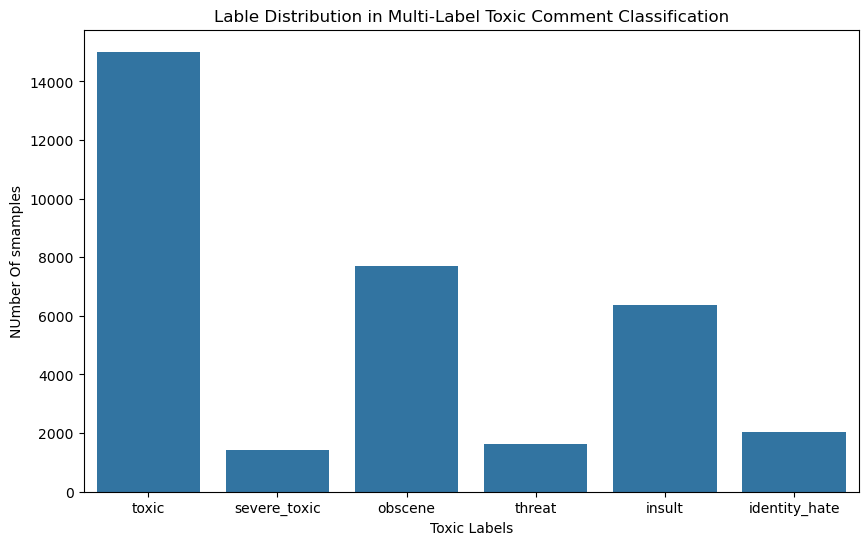

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.title("Lable Distribution in Multi-Label Toxic Comment Classification")
sns.barplot(x=labels_counts.index, y=labels_counts.values)
plt.ylabel("NUmber Of smamples")
plt.xlabel("Toxic Labels")
plt.show()

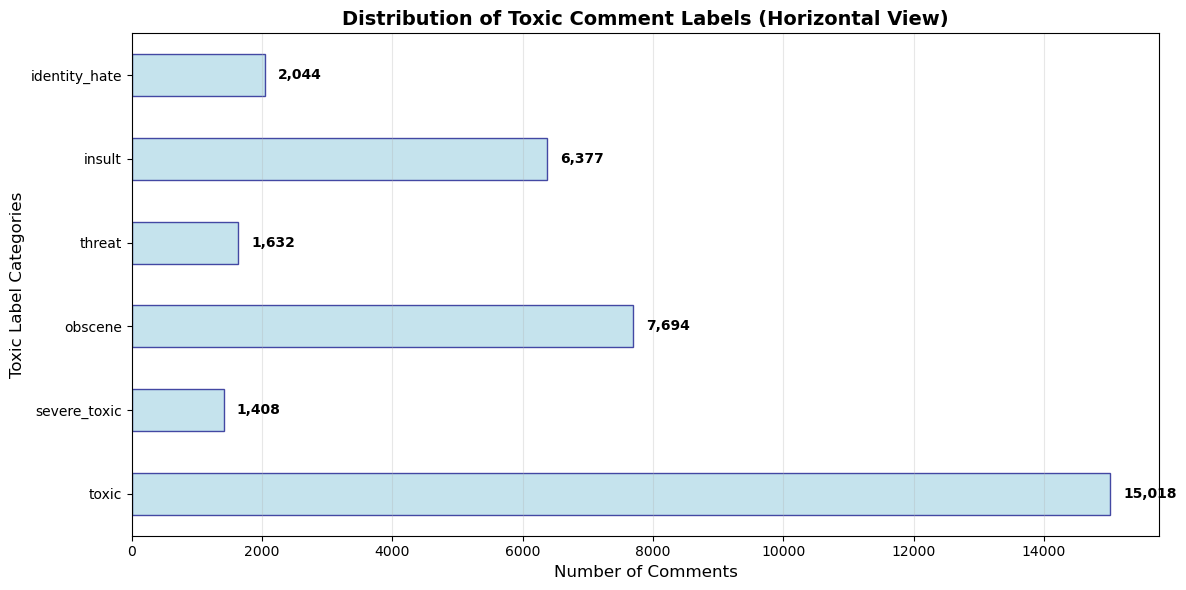

In [27]:
plt.figure(figsize=(12, 6))

# Create horizontal bar chart with proper method call
ax = labels_counts.plot(kind='barh', color='lightblue', edgecolor='navy', alpha=0.7)

plt.title("Distribution of Toxic Comment Labels (Horizontal View)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Comments", fontsize=12)
plt.ylabel("Toxic Label Categories", fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Add value labels on the bars
for i, (label, value) in enumerate(labels_counts.items()):
    plt.text(value + 200, i, f'{value:,}', va='center', ha='left', fontweight='bold')

plt.tight_layout()
plt.show()
